<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_summer_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

order_baseline=pd.read_csv("/content/drive/MyDrive/ESAA_OB_pj/order_baseline.csv")
customer_features_baseline=pd.read_csv("/content/drive/MyDrive/ESAA_OB_pj/customer_features_baseline.csv")

In [ ]:
order_baseline.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,payment_value,payment_count,payment_installments_mean,payment_type_nunique,item_count,product_count,seller_count,product_price_sum,freight_value_sum
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,38.71,3.0,1.0,2.0,1.0,1.0,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,BA,141.46,1.0,1.0,1.0,1.0,1.0,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,GO,179.12,1.0,3.0,1.0,1.0,1.0,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,RN,72.20,1.0,1.0,1.0,1.0,1.0,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,28.62,1.0,1.0,1.0,1.0,1.0,1.0,19.90,8.72


In [ ]:
customer_features_baseline.head(5)

,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary,avg_payment_value,total_items,avg_items_per_order,total_product_price,total_freight_value,unique_products,unique_sellers,recency,tenure
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56,2018-05-10 10:56,1,141.90,141.90,1,1.0,129.90,12.00,1,1,112,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11,2018-05-07 11:11,1,27.19,27.19,1,1.0,18.90,8.29,1,1,115,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05,2017-03-10 21:05,1,86.22,86.22,1,1.0,69.00,17.22,1,1,537,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29,2017-10-12 20:29,1,43.62,43.62,1,1.0,25.99,17.63,1,1,321,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45,2017-11-14 19:45,1,196.89,196.89,1,1.0,180.00,16.89,1,1,288,0


In [ ]:
order_baseline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_zip_code_prefix       99441 non-null  int64  
 10  customer_city                  99441 non-null  object 
 11  customer_state                 99441 non-null  object 
 12  payment_value                  99440 non-null 

In [ ]:
customer_features_baseline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_unique_id   93358 non-null  object 
 1   first_purchase_date  93358 non-null  object 
 2   last_purchase_date   93358 non-null  object 
 3   frequency            93358 non-null  int64  
 4   monetary             93358 non-null  float64
 5   avg_payment_value    93358 non-null  float64
 6   total_items          93358 non-null  int64  
 7   avg_items_per_order  93358 non-null  float64
 8   total_product_price  93358 non-null  float64
 9   total_freight_value  93358 non-null  float64
 10  unique_products      93358 non-null  int64  
 11  unique_sellers       93358 non-null  int64  
 12  recency              93358 non-null  int64  
 13  tenure               93358 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 10.0+ MB


# EDA

### 1. Date Column Conversion and Delivery Delay Calculation : 날짜 열 변환 및 배송 지연 계산

In [ ]:
import numpy as np

# Convert relevant columns to datetime objects
# 관련 열을 datetime 객체로 변환
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    order_baseline[col] = pd.to_datetime(order_baseline[col], errors='coerce')

# Calculate actual delivery time and estimated delivery time
# 실제 배송 시간과 예상 배송 시간 계산
order_baseline['actual_delivery_time'] = (order_baseline['order_delivered_customer_date'] - order_baseline['order_purchase_timestamp']).dt.days
order_baseline['estimated_delivery_time'] = (order_baseline['order_estimated_delivery_date'] - order_baseline['order_purchase_timestamp']).dt.days

# Calculate delivery delay (positive value means late delivery, negative means early)
# 배송 지연 계산(양의 값은 배송 지연을 의미하고, 음의 값은 조기 배송을 의미합니다)
order_baseline['delivery_delay'] = (order_baseline['order_delivered_customer_date'] - order_baseline['order_estimated_delivery_date']).dt.days

# Fill NaN delivery_delay for cancelled orders with a placeholder (e.g., a large negative number or 0 if appropriate, for now let's use 0)
# Or, more accurately, handle them based on business logic. For EDA, we might just filter them out for delay analysis or treat them as extreme delays.
# For now, let's fill NaNs with a value that indicates no delay calculation possible (e.g., NaN, and then we will filter them for specific visualizations).
# For churn analysis, cancelled orders are critical, but for delivery delay calculation, they might not have a delivered date.

# 취소된 주문에 대한 NaN 배송 지연을 자리 표시자로 채우세요(예: 큰 음수 또는 적절한 경우 0, 지금은 0을 사용합시다)
# 또는 더 정확하게는 비즈니스 논리에 따라 처리합니다. EDA의 경우 지연 분석을 위해 필터링하거나 극단적인 지연으로 취급할 수 있습니다.
# 지금은 지연 계산이 불가능하다는 값(예: NaN)으로 NaN을 채운 다음 특정 시각화를 위해 필터링하겠습니다.
# 이탈 분석을 위해서는 취소된 주문이 중요하지만, 배송 지연 계산을 위해서는 배송 날짜가 없을 수도 있습니다.

# Display summary statistics of delivery_delay
# delivery_delay 요약 통계 표시
display(order_baseline[['actual_delivery_time', 'estimated_delivery_time', 'delivery_delay']].describe())

,actual_delivery_time,estimated_delivery_time,delivery_delay
count,96476.000000,99441.000000,96476.000000
mean,12.094086,23.403958,-11.876881
std,9.551746,8.829562,10.183854
min,0.000000,1.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


### 2. Visualize Delivery Delay Distribution : 배송 지연 분포 시각화

- 조기 배송의 경우가 더 많다.
- 매우 조기 배송의 경우 (예상 배송 시간이 길게 잡힌 경우?) : max 155
- 매우 배송 지연의 경우 (실제 배송 시간이 길게 잡힌 경우?): max 209
- 일반적으로 -30~10이다.

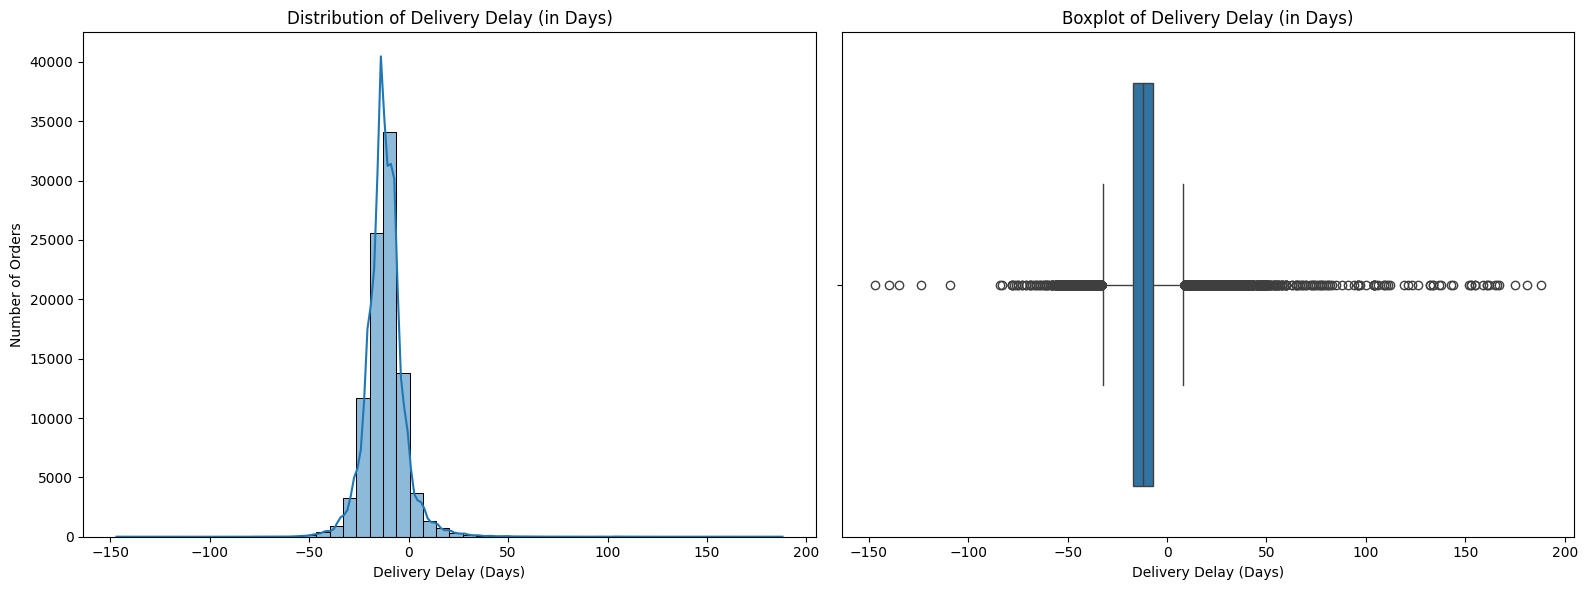

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values for delivery_delay for visualization
# 시각화를 위해 delivery_delay에 대한 NaN 값 필터링
delay_data = order_baseline['delivery_delay'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of delivery delay
# delivery delay의 히스토그램
sns.histplot(delay_data, bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Delivery Delay (in Days)')
ax[0].set_xlabel('Delivery Delay (Days)')
ax[0].set_ylabel('Number of Orders')

# Boxplot to show outliers and spread more clearly
# 이상값을 표시하고 더 명확하게 분포시키기 위한 박스 플롯
sns.boxplot(x=delay_data, ax=ax[1])
ax[1].set_title('Boxplot of Delivery Delay (in Days)')
ax[1].set_xlabel('Delivery Delay (Days)')

plt.tight_layout()
plt.show()

### 3. Regional Analysis: Average Delivery Delay by Customer State : 지역 분석: 고객 상태별 평균 배송 지연

- AL:
- MA:
- SE:
- ES:
- BA:
- CE:
- MS:
- SP: 상파울루
- PI:
- SC:
- RJ:
- DF:
- TO:
- GO:
- MG:
- PB:
- PE:
- PR:
- RN:
- RS:
- PA:
- MT:
- RR:
- AM:
- AP:
- RO:
- AC:

/tmp/ipykernel_731/1576102507.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='delivery_delay', data=avg_delay_by_state, palette='viridis')


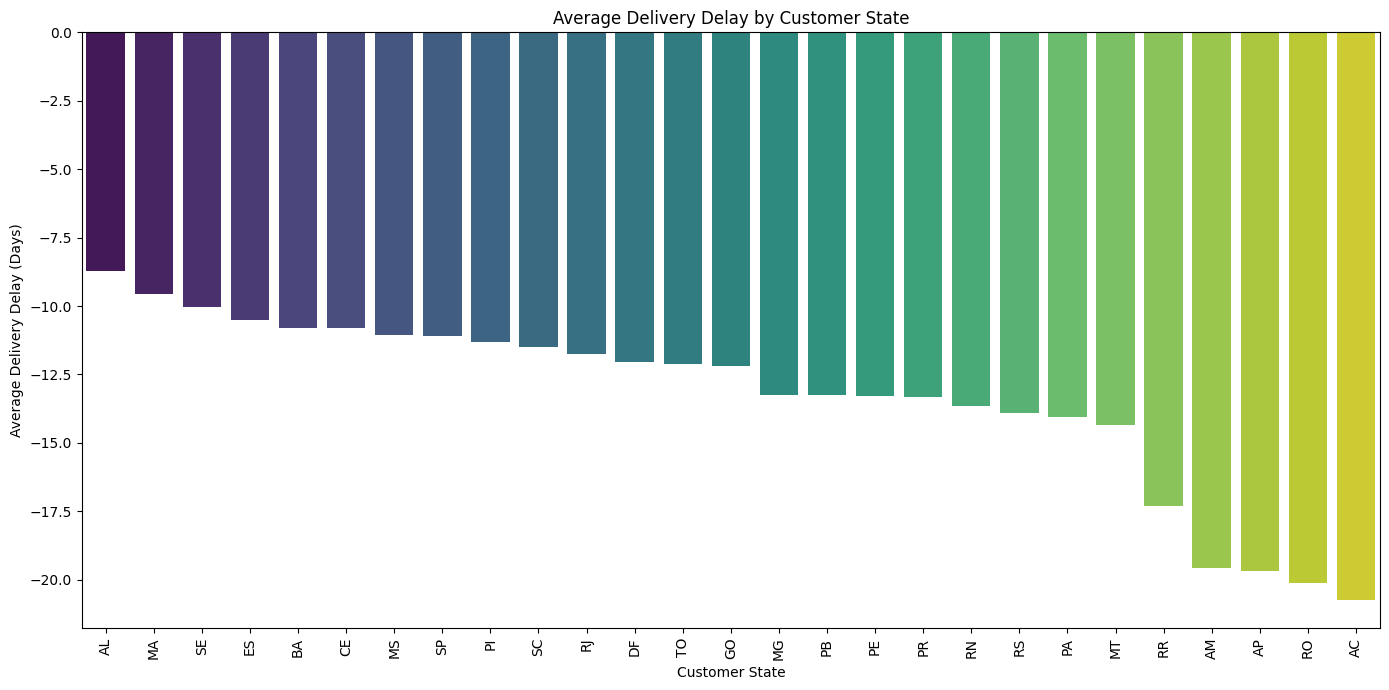

In [ ]:
# Calculate average delivery delay per state, excluding NaNs in delivery_delay
# delivery_delay에서 NaN을 제외한 상태당 평균 배송 지연 계산
avg_delay_by_state = order_baseline.groupby('customer_state')['delivery_delay'].mean().sort_values(ascending=False).reset_index()

fig = plt.figure(figsize=(14, 7))
sns.barplot(x='customer_state', y='delivery_delay', data=avg_delay_by_state, palette='viridis')
plt.title('Average Delivery Delay by Customer State')
plt.xlabel('Customer State')
plt.ylabel('Average Delivery Delay (Days)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4. Order Status Distribution (Churn Indicator) : 주문 상태 분포(전환 표시기)

/tmp/ipykernel_731/1172287556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status_counts.index, y=order_status_counts.values, palette='magma')


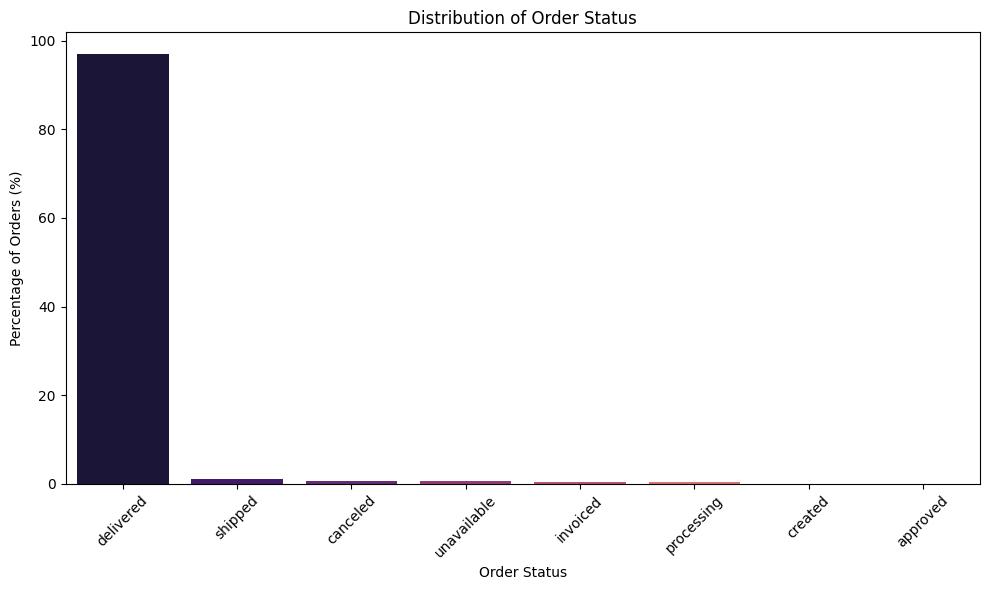

,proportion
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


In [ ]:
# Analyze the distribution of order statuses
# 주문 상태 분포 분석
order_status_counts = order_baseline['order_status'].value_counts(normalize=True) * 100

fig = plt.figure(figsize=(10, 6))
sns.barplot(x=order_status_counts.index, y=order_status_counts.values, palette='magma')
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Percentage of Orders (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(order_status_counts)

### 5. Relationship between Delivery Delay and Order Status : 배송 지연과 주문 상태 간의 관계

**주문 상태**
- invoiced: 송장 처리된
- shipped: 배달된
- processing: 처리.
- unavailable: 사용할 수 없음
- canceled: 취소된 (배송이 지연되어서 취소됐는지를 알아야 할 것 같음)
- delivered: 배달했다
- created: 창조했다
- approved: 승인된


/tmp/ipykernel_731/3723274491.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='order_status', y='days_past_estimated_delivery', data=mis_delivery_potential, palette='coolwarm')


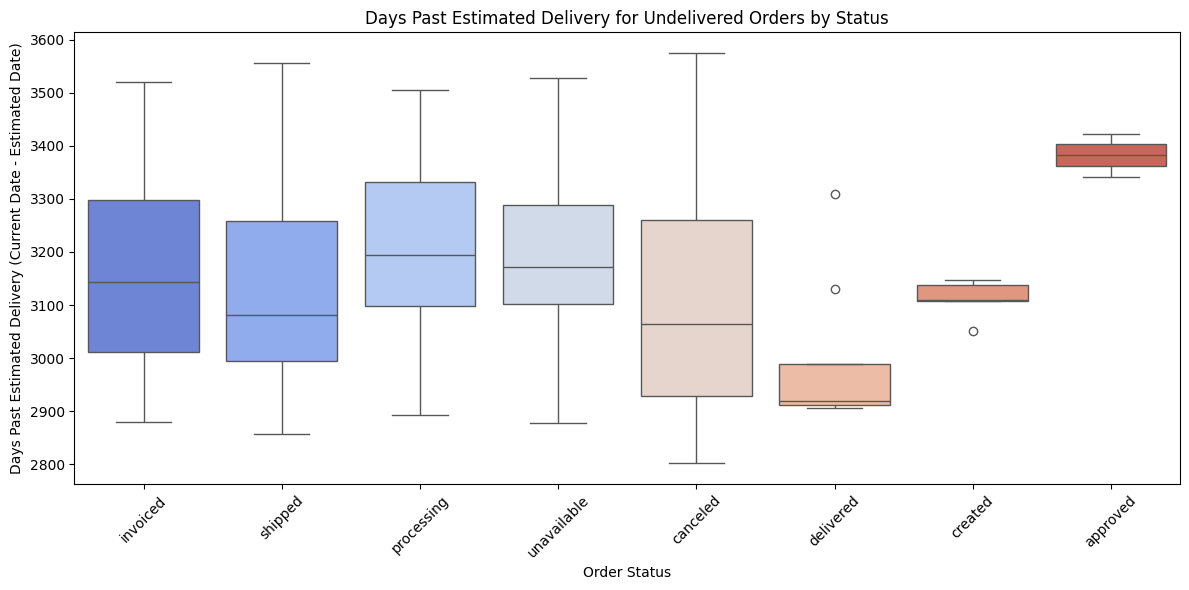

Number of canceled orders: 625


In [ ]:
# Explore delivery delay for non-delivered orders (potential churn risk)
# We'll focus on 'canceled' and 'unavailable' orders as direct churn indicators
# 배송되지 않은 주문의 배송 지연(잠재적 이탈 위험) 살펴보기
# 우리는 직접 이탈 지표로서 '취소된' 주문과 '사용 불가능한' 주문에 집중할 것입니다

# Filter for orders that are not delivered but have some estimated/actual dates for comparison
# 배송되지 않았지만 비교할 수 있는 예상/실제 날짜가 있는 주문 필터링
churn_related_statuses = ['canceled', 'unavailable', 'invoiced', 'shipped', 'processing', 'approved']

# Calculate average delay for delivered vs. non-delivered (or churn-related) orders
# 배송된 주문과 배송되지 않은 주문(또는 이탈 관련)의 평균 지연 시간 계산
delivered_orders = order_baseline[order_baseline['order_status'] == 'delivered']['delivery_delay'].dropna()

# For other statuses, `delivery_delay` might be NaN, so we'll look at the time from purchase if no delivery date exists
# Let's consider the duration from purchase to last known event for non-delivered orders
# 다른 상태의 경우 '배송 지연'이 NaN일 수 있으므로 배송 날짜가 없는 경우 구매 후 시간을 살펴보겠습니다
# 배송되지 않은 주문의 경우 구매부터 마지막으로 알려진 이벤트까지의 기간을 고려해 보겠습니다

# Focus on orders where 'order_delivered_customer_date' is NaN but `order_estimated_delivery_date` exists
# This would indicate a potential missed delivery
# 'order_delivered_customer_date'가 NaN이지만 'order_estimated_delivery_date'가 존재하는 주문에 집중하세요
# 이것은 잠재적인 배송 누락을 나타낼 수 있습니다
mis_delivery_potential = order_baseline[
    order_baseline['order_delivered_customer_date'].isna() &
    order_baseline['order_estimated_delivery_date'].notna()
].copy()

if not mis_delivery_potential.empty:
    mis_delivery_potential['days_past_estimated_delivery'] = \
        (pd.to_datetime('today') - mis_delivery_potential['order_estimated_delivery_date']).dt.days

    fig = plt.figure(figsize=(12, 6))
    sns.boxplot(x='order_status', y='days_past_estimated_delivery', data=mis_delivery_potential, palette='coolwarm')
    plt.title('Days Past Estimated Delivery for Undelivered Orders by Status')
    plt.xlabel('Order Status')
    plt.ylabel('Days Past Estimated Delivery (Current Date - Estimated Date)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No undelivered orders with estimated delivery dates found to analyze 'days_past_estimated_delivery'.")

# Compare delay characteristics between 'delivered' and 'canceled' orders specifically
# Note: 'canceled' orders often don't have a delivery date, so 'delivery_delay' will be NaN.
# We can look at `order_purchase_timestamp` to `order_approved_at` or `order_delivered_carrier_date` for these.
# '배송된' 주문과 '취소된' 주문 간의 지연 특성을 구체적으로 비교합니다
# 참고: '취소된' 주문에는 배송 날짜가 없는 경우가 많기 때문에 '배송_지연'은 NaN이 됩니다.
# 이를 위해 'order_purchase_timesamp'에서 'order_approved_at' 또는 'order_delivered_carrier_date'로 볼 수 있습니다.

# For 'canceled' orders, we can look at the time until cancellation or absence of delivery events.
# '취소된' 주문의 경우, 배송 이벤트가 취소되거나 부재할 때까지의 시간을 확인할 수 있습니다.
canceled_orders = order_baseline[order_baseline['order_status'] == 'canceled']

if not canceled_orders.empty:
    print(f"Number of canceled orders: {len(canceled_orders)}")
    # Further analysis could involve looking at features of canceled orders
    # e.g., what was the average time between purchase and cancellation request
    # For simplicity, we'll just acknowledge their count for now as a churn signal
    # 추가 분석에는 취소된 주문의 특징을 살펴보는 것이 포함될 수 있습니다
    # 예: 구매와 취소 요청 사이의 평균 시간은 얼마입니까
    # 간단히 하기 위해, 우리는 일단 그들의 수를 이탈 신호로 인정할 것입니다
else:
    print("No canceled orders found.")

### 6. 재구매 관련

- 특정 우편번호에서 많은 구매가 이루어지고 있다는 점: customer_zip_code_prefix로 count 계산
- 특정 지역에서 많은 구매가 이루어지고 있다는 점: customer_city로 count 계산

In [ ]:
# frequency > 1 인 것들만
filtered_customers = customer_features_baseline[customer_features_baseline['frequency'] > 1]
display(filtered_customers.head())

,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary,avg_payment_value,total_items,avg_items_per_order,total_product_price,total_freight_value,unique_products,unique_sellers,recency,tenure
104,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13,2018-01-14 7:36,2,354.37,177.185,2,1.0,317.89,36.48,2,2,228,170
243,00a39521eb40f7012db50455bf083460,2018-05-23 20:14,2018-06-03 10:12,2,123.25,61.625,2,1.0,81.45,41.80,2,2,88,10
305,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25,2017-03-21 19:25,2,126.20,63.100,2,1.0,99.80,26.40,2,2,526,0
404,011575986092c30523ecb71ff10cb473,2018-02-17 15:54,2018-04-18 21:58,2,214.90,107.450,2,1.0,182.90,32.00,2,2,133,60
419,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51,2018-02-15 11:40,2,236.30,118.150,3,1.5,183.43,52.87,2,2,196,176


In [ ]:
zip_code_frequency = order_baseline['customer_zip_code_prefix'].value_counts().reset_index()
zip_code_frequency.columns = ['customer_zip_code_prefix', 'count']
display(zip_code_frequency)

,customer_zip_code_prefix,count
0,22790,142
1,24220,124
2,22793,121
3,24230,117
4,22775,110
...,...,...
14989,76842,1
14990,53421,1
14991,65440,1
14992,65095,1


In [ ]:
zip_code_city_map = order_baseline[['customer_zip_code_prefix', 'customer_city']].drop_duplicates()
zip_code_frequency_with_city = pd.merge(zip_code_frequency, zip_code_city_map, on='customer_zip_code_prefix', how='left')
display(zip_code_frequency_with_city)

,customer_zip_code_prefix,count,customer_city
0,22790,142,rio de janeiro
1,24220,124,niteroi
2,22793,121,rio de janeiro
3,24230,117,niteroi
4,22775,110,rio de janeiro
...,...,...,...
15029,76842,1,mutum parana
15030,53421,1,paulista
15031,65440,1,sao benedito do rio preto
15032,65095,1,sao luis


In [ ]:
city_frequency = order_baseline['customer_city'].value_counts().reset_index()
city_frequency.columns = ['customer_city', 'count']
display(city_frequency)

,customer_city,count
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
...,...,...
4114,conceicao do almeida,1
4115,japaratuba,1
4116,mariental,1
4117,francisco santos,1


/tmp/ipykernel_3895/2887555724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_city', y='count', data=top_10_cities, palette='viridis')


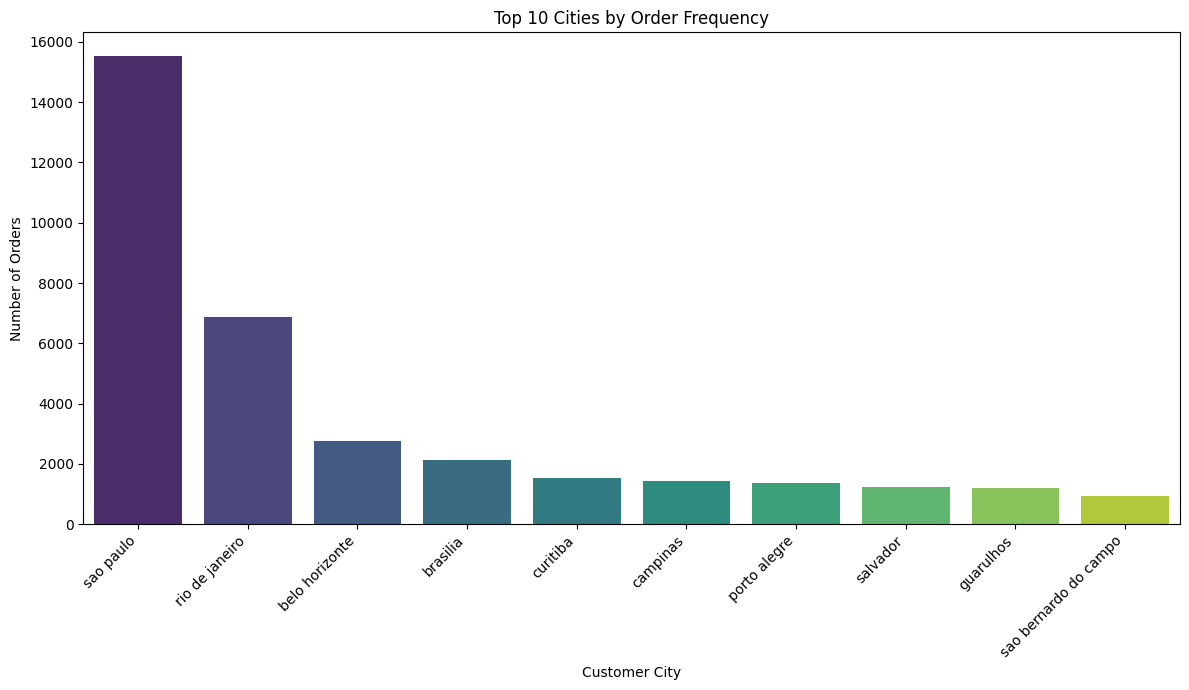

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by count and get the top 10 cities
top_10_cities = city_frequency.head(10)

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='customer_city', y='count', data=top_10_cities, palette='viridis')
plt.title('Top 10 Cities by Order Frequency')
plt.xlabel('Customer City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 리뷰 NLP 감성 분석

order_baseline에 먼저 병합 → 텍스트 전처리 → 감성분석 → customer 단위로 집계 → customer_features_baseline에 병합

### 1. 리뷰 데이터 로드 및 탐색

In [ ]:
import pandas as pd

reviews = pd.read_csv("/content/drive/MyDrive/ESAA_OB_pj/olist_order_reviews_dataset.csv")
print(reviews.info())
print(reviews.isnull().sum())

# order_id 기준 중복 리뷰가 있는지 확인 (Olist는 간혹 재요청 리뷰가 존재)
print(reviews.duplicated(subset='order_id').sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
551


### 2. order_id 중복 제거

order_id 하나에 리뷰가 여러 개 붙는 경우가 있어서, 병합 전에 최신 리뷰 하나만 남겨야 1:1 병합 가능

In [ ]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews_dedup = (
    reviews.sort_values('review_creation_date')
    .drop_duplicates(subset='order_id', keep='last')
)

### 3. 텍스트 결합 및 결측 처리

In [ ]:
reviews_dedup['review_comment_title'] = reviews_dedup['review_comment_title'].fillna('')
reviews_dedup['review_comment_message'] = reviews_dedup['review_comment_message'].fillna('')

reviews_dedup['review_text'] = (
    reviews_dedup['review_comment_title'] + ' ' + reviews_dedup['review_comment_message']
).str.strip()

reviews_dedup['has_text'] = reviews_dedup['review_text'] != ''

### 4. order_baseline에 병합 (order 단위)

In [ ]:
order_baseline = order_baseline.merge(
    reviews_dedup[['order_id', 'review_score', 'review_text', 'has_text',
                   'review_creation_date', 'review_answer_timestamp']],
    on='order_id',
    how='left',
    suffixes=('', '_review')
)

### 5. 포르투갈어 텍스트 전처리

포르투갈어는 억양 부호(á, ã, ç, é, õ 등)가 의미를 바꾸는 경우가 많아서 accent를 제거하지 않아야 함.

In [ ]:
import re

def clean_pt_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URL 제거
    text = re.sub(r'[\r\n\t]+', ' ', text)                  # 개행/탭 제거
    text = re.sub(r'[^a-záàâãéêíóôõúüç\s]', ' ', text)      # 특수문자/숫자 제거 (포르투갈어 문자 보존)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

order_baseline['review_text_clean'] = order_baseline['review_text'].fillna('').apply(clean_pt_text)

### 6. 감성분석 파이프라인 구축

다국어 사전학습 모델 이용

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, use_safetensors=True)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from tqdm import tqdm

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0,
    truncation=True,
    max_length=128
)

mask = order_baseline['review_text_clean'].str.len() > 0
texts = order_baseline.loc[mask, 'review_text_clean'].tolist()

batch_size = 128
results = []

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    batch_results = sentiment_pipeline(batch, truncation=True, max_length=128)
    results.extend(batch_results)

order_baseline.loc[mask, 'sentiment_label'] = [r['label'] for r in results]
order_baseline.loc[mask, 'sentiment_score']  = [r['score'] for r in results]

100%|██████████| 331/331 [07:27<00:00,  1.35s/it]


### 7. 감성 라벨을 수치화

In [ ]:
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
order_baseline['sentiment_numeric'] = order_baseline['sentiment_label'].str.lower().map(sentiment_map)
order_baseline['sentiment_weighted'] = order_baseline['sentiment_numeric'] * order_baseline['sentiment_score']

### 8-a. 주제별(Topic) 감성 — 키워드 기반 aspect 태깅

In [ ]:
topic_keywords = {
    'delivery':          ['entrega', 'prazo', 'atraso', 'chegou', 'transportadora', 'correio', 'demorou'],
    'product_quality':   ['qualidade', 'produto', 'defeito', 'quebrado', 'estragado', 'ruim', 'excelente'],
    'customer_service':  ['atendimento', 'suporte', 'resposta', 'contato', 'sac'],
    'price_value':       ['preço', 'valor', 'caro', 'barato', 'custo'],
}

def tag_topics(text):
    return [topic for topic, kws in topic_keywords.items() if any(kw in text for kw in kws)]

order_baseline['review_topics'] = order_baseline['review_text_clean'].apply(tag_topics)

### 9-a. customer 단위로 집계

In [ ]:
review_cols = ['customer_unique_id', 'order_id', 'sentiment_numeric',
               'sentiment_weighted', 'review_score', 'review_topics']

order_review = order_baseline[review_cols]

# 전체 요약 피처
customer_review_agg = order_review.groupby('customer_unique_id').agg(
    avg_review_score=('review_score', 'mean'),
    avg_sentiment=('sentiment_numeric', 'mean'),
    avg_sentiment_weighted=('sentiment_weighted', 'mean'),
    review_count=('order_id', 'count')
).reset_index()

# 토픽별 평균 감성
topic_df = order_review.explode('review_topics')
customer_topic_sentiment = (
    topic_df.groupby(['customer_unique_id', 'review_topics'])['sentiment_weighted']
    .mean()
    .unstack('review_topics')
    .add_prefix('sentiment_')
    .reset_index()
)

customer_review_features = customer_review_agg.merge(
    customer_topic_sentiment, on='customer_unique_id', how='left'
)

### 10-a. customer_features_baseline에 최종 병합

In [ ]:
customer_features_baseline = customer_features_baseline.merge(
    customer_review_features,
    on='customer_unique_id',
    how='left'
)

In [ ]:
customer_features_baseline.head()

,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary,avg_payment_value,total_items,avg_items_per_order,total_product_price,total_freight_value,...,recency,tenure,avg_review_score,avg_sentiment,avg_sentiment_weighted,review_count,sentiment_customer_service,sentiment_delivery,sentiment_price_value,sentiment_product_quality
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56,2018-05-10 10:56,1,141.90,141.90,1,1.0,129.90,12.00,...,112,0,5.0,1.0,0.930237,1,NaN,NaN,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11,2018-05-07 11:11,1,27.19,27.19,1,1.0,18.90,8.29,...,115,0,4.0,NaN,NaN,1,NaN,NaN,NaN,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05,2017-03-10 21:05,1,86.22,86.22,1,1.0,69.00,17.22,...,537,0,3.0,NaN,NaN,1,NaN,NaN,NaN,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29,2017-10-12 20:29,1,43.62,43.62,1,1.0,25.99,17.63,...,321,0,4.0,1.0,0.534706,1,NaN,NaN,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45,2017-11-14 19:45,1,196.89,196.89,1,1.0,180.00,16.89,...,288,0,5.0,NaN,NaN,1,NaN,NaN,NaN,NaN


### 8-b. LDA 이용 필요 라이브러리 설치

In [ ]:
!pip install gensim spacy
!python -m spacy download pt_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 117.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### 9-b. 포르투갈어 형태소 분석 (표제어 추출) + 불용어 제거

In [ ]:
import spacy
from tqdm import tqdm

nlp = spacy.load('pt_core_news_sm', disable=['ner', 'parser'])

# 리뷰 도메인 특화 불용어 (일반적인 spaCy 불용어에 추가)
custom_stopwords = {'produto', 'compra', 'comprar', 'pedido', 'olist', 'loja'}

def preprocess_lda(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.pos_ in ('NOUN', 'ADJ', 'VERB')
        and not token.is_stop
        and token.lemma_ not in custom_stopwords
        and len(token.lemma_) > 2
    ]
    return tokens

# 텍스트가 있는 리뷰만 대상 (앞서 만든 mask 재사용)
lda_texts = order_baseline.loc[mask, 'review_text_clean'].tolist()

tokenized_docs = [preprocess_lda(doc) for doc in tqdm(lda_texts)]

100%|██████████| 42250/42250 [02:35<00:00, 271.20it/s]


In [ ]:
tokenized_docs = []
for doc in tqdm(nlp.pipe(lda_texts, batch_size=100), total=len(lda_texts)):
    tokens = [
        token.lemma_ for token in doc
        if token.pos_ in ('NOUN', 'ADJ', 'VERB')
        and not token.is_stop
        and token.lemma_ not in custom_stopwords
        and len(token.lemma_) > 2
    ]
    tokenized_docs.append(tokens)

100%|██████████| 42250/42250 [00:28<00:00, 1464.04it/s]


### 10-b. 사전(Dictionary) 및 코퍼스 생성

In [ ]:
from gensim import corpora

dictionary = corpora.Dictionary(tokenized_docs)

# 너무 드물거나(2건 미만) 너무 흔한(50% 이상 문서에 등장) 단어 제거
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

### 11-b. LDA 모델 학습

In [ ]:


lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,   # 6 → 4로 조정
    random_state=42,
    passes=10,
    iterations=100,
    alpha='auto',
    per_word_topics=True
)

NameError: name 'LdaModel' is not defined

### 12-b. 토픽별 키워드 확인 (해석 및 라벨링용)

In [ ]:
for topic_id, words in lda_model.print_topics(num_words=10):
    print(f"토픽 {topic_id}: {words}\n")

토픽 0: 0.093*"recebi" + 0.048*"comprei" + 0.042*"dia" + 0.022*"receber" + 0.020*"problema" + 0.019*"lannister" + 0.017*"site" + 0.013*"empresa" + 0.012*"recebir" + 0.012*"aguardar"

토픽 1: 0.106*"prazo" + 0.101*"entregar" + 0.078*"chegar" + 0.053*"entrega" + 0.044*"recomendar" + 0.034*"qualidade" + 0.032*"gostar" + 0.032*"bom" + 0.029*"super" + 0.029*"recomendo"

토픽 2: 0.032*"achar" + 0.029*"preço" + 0.029*"bonito" + 0.023*"funcionar" + 0.022*"relógio" + 0.022*"material" + 0.020*"péssimo" + 0.019*"cliente" + 0.019*"rapir" + 0.019*"ficar"

토픽 3: 0.102*"vir" + 0.029*"correio" + 0.025*"nota" + 0.021*"foto" + 0.020*"errar" + 0.018*"pedir" + 0.018*"frete" + 0.015*"troca" + 0.014*"embalagem" + 0.013*"diferente"



#### lannister가 노이즈가 아닌지? -> 제품명이 침투함

In [ ]:
print(dictionary.token2id.get('lannister'))
print(dictionary.dfs.get(dictionary.token2id['lannister']))  # 몇 개 문서에 등장하는지

25
1089


#### 상품명 제외하기

In [ ]:
# 상품명일 가능성이 높은 고빈도 명사를 자동 탐지
from collections import Counter

word_doc_count = Counter()
for doc in tokenized_docs:
    for word in set(doc):
        word_doc_count[word] += 1

# 상위 30개 확인 (제품명 성격의 단어가 있는지 눈으로 검토)
for word, count in word_doc_count.most_common(30):
    print(word, count)

prazo 8403
entregar 7763
chegar 6121
recebi 4468
entrega 3996
recomendar 3566
vir 3073
qualidade 2786
bom 2486
super 2454
gostar 2426
recomendo 2373
comprei 2373
excelente 2238
rápido 2129
dia 1844
esperar 1391
perfeito 1312
otimo 1236
ótimo 1177
site 1130
satisfeito 1111
lannister 1089
prever 1074
receber 1022
problema 1017
correio 926
adorar 902
parabéns 872
achar 837


In [ ]:
# 'lannister'가 포함된 문서 인덱스 찾기
lannister_idx = [i for i, doc in enumerate(tokenized_docs) if 'lannister' in doc]
print(f"lannister가 등장한 문서 수: {len(lannister_idx)}")

# 원본 리뷰 텍스트 확인 (lda_texts는 전처리 전 원문)
for i in lannister_idx[:15]:
    print(repr(lda_texts[i]))
    print('---')

lannister가 등장한 문서 수: 1089
'nota dez obrigado pela atenção lojas lannister perfeito em tudo'
---
'quero o cartão de crédito das lojas lannister minha satisfação é plena'
---
'ofertado pago lannister não interessa se opera market place a compra foi feita no site da lannister e pago para lannister se tiver que ajuizar vai ser contra lannister e lá faça o regresso contra o fornecedor'
---
'recomendo trabalho com profissionalismo das lojas lannister indico com certeza'
---
'ótimo produto original e com muita qualidade recomendo a todos a loja parceira da lannister'
---
'melhor loja do brasil primeira vez que comprei na lannister online e agora trocarei o ml pela lannister com'
---
'a loja lannister e a entrega foi ótimo já o produto não é tão bom quanto aparenta mas da pra uso'
---
'boneca não veio de acordo com as especificações que eu ví no quiosque da lannister'
---
'bom sempre confiei nas redes lannister'
---
'produto entregue muito antes do prazo perfeito recomendo a todos sempre compr

In [ ]:
# lannister 걸러내기
custom_stopwords = {
    'produto', 'compra', 'comprar', 'pedido', 'olist', 'loja', 'lojas', 'site',
    'bom', 'ótimo', 'otimo', 'péssimo', 'excelente', 'perfeito', 'ruim',
    'relógio', 'cartucho',
    'lannister',  # 실제 판매자 상호명으로 확인됨 — 리뷰 주제와 무관
}

In [ ]:
nlp = spacy.load('pt_core_news_sm', disable=['parser'])  # ner는 다시 활성화

def preprocess_lda(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.pos_ in ('NOUN', 'ADJ', 'VERB')
        and not token.is_stop
        and token.lemma_ not in custom_stopwords
        and token.ent_type_ != 'ORG'   # 조직/상호명으로 인식되면 제외
        and len(token.lemma_) > 2
    ]
    return tokens

In [ ]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

coherence_scores = []
topic_range = range(3, 9)

for n in topic_range:
    model = LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=n,
        random_state=42, passes=10, iterations=100, alpha='auto'
    )
    coherence_model = CoherenceModel(
        model=model, texts=tokenized_docs, dictionary=dictionary, coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"num_topics={n}, coherence={score:.4f}")

plt.plot(topic_range, coherence_scores, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('Topic Coherence by Number of Topics')
plt.show()

NameError: name 'LdaModel' is not defined

In [ ]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10,
    iterations=100,
    alpha='auto',
    per_word_topics=True
)

In [ ]:
for topic_id, words in lda_model.print_topics(num_words=10):
    print(f"토픽 {topic_id}: {words}\n")

토픽 0: 0.093*"recebi" + 0.048*"comprei" + 0.042*"dia" + 0.022*"receber" + 0.020*"problema" + 0.019*"lannister" + 0.017*"site" + 0.013*"empresa" + 0.012*"recebir" + 0.012*"aguardar"

토픽 1: 0.106*"prazo" + 0.101*"entregar" + 0.078*"chegar" + 0.053*"entrega" + 0.044*"recomendar" + 0.034*"qualidade" + 0.032*"gostar" + 0.032*"bom" + 0.029*"super" + 0.029*"recomendo"

토픽 2: 0.032*"achar" + 0.029*"preço" + 0.029*"bonito" + 0.023*"funcionar" + 0.022*"relógio" + 0.022*"material" + 0.020*"péssimo" + 0.019*"cliente" + 0.019*"rapir" + 0.019*"ficar"

토픽 3: 0.102*"vir" + 0.029*"correio" + 0.025*"nota" + 0.021*"foto" + 0.020*"errar" + 0.018*"pedir" + 0.018*"frete" + 0.015*"troca" + 0.014*"embalagem" + 0.013*"diferente"



#### LDA 재학습

In [ ]:
custom_stopwords = {
    'produto', 'compra', 'comprar', 'pedido', 'olist', 'loja', 'lojas', 'site',
    'bom', 'ótimo', 'otimo', 'péssimo', 'excelente', 'perfeito', 'ruim',
    'relógio', 'cartucho', 'lannister'
}

# 전처리 → dictionary → corpus → LDA 재학습
tokenized_docs = [preprocess_lda(doc) for doc in tqdm(lda_texts)]
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=10, no_above=0.3)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

lda_model = LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=4,
    random_state=42, passes=10, iterations=100, alpha='auto', per_word_topics=True
)

100%|██████████| 42250/42250 [03:52<00:00, 182.07it/s]


In [ ]:
for topic_id, words in lda_model.print_topics(num_words=10):
    print(f"토픽 {topic_id}: {words}\n")

토픽 0: 0.043*"achar" + 0.038*"bonito" + 0.030*"funcionar" + 0.028*"demorar" + 0.026*"dever" + 0.026*"frete" + 0.024*"poder" + 0.021*"cumprir" + 0.019*"ótima" + 0.017*"vier"

토픽 1: 0.123*"prazo" + 0.118*"entregar" + 0.090*"chegar" + 0.057*"entrega" + 0.051*"recomendar" + 0.040*"qualidade" + 0.037*"gostar" + 0.034*"super" + 0.034*"recomendo" + 0.031*"rápido"

토픽 2: 0.120*"vir" + 0.025*"foto" + 0.023*"errar" + 0.020*"faltar" + 0.019*"cor" + 0.018*"lir" + 0.018*"ficar" + 0.017*"troca" + 0.017*"nao" + 0.016*"embalagem"

토픽 3: 0.089*"recebi" + 0.046*"comprei" + 0.041*"dia" + 0.021*"receber" + 0.020*"correio" + 0.019*"problema" + 0.017*"nota" + 0.014*"enviar" + 0.012*"pedir" + 0.012*"empresa"



#### 라벨 붙이기

In [ ]:
topic_label_map = {
    0: 'quality_expectation',      # 품질/기대 충족 (achar, bonito, funcionar, cumprir)
    1: 'delivery_satisfaction',    # 배송 만족/추천 (prazo, entrega, recomendar, rápido)
    2: 'wrong_missing_item',       # 오배송/누락/교환 (errar, faltar, cor, troca)
    3: 'purchase_process_issue'    # 구매~수령 프로세스/문제 (recebi, correio, problema, nota)
}

### 13-b. 고객 단위 집계 + customer_features_baseline 병합

In [ ]:
# Get the topic distribution for each document from the LDA model
doc_topics = lda_model.get_document_topics(corpus, minimum_probability=0.0)

# Initialize columns in order_baseline for LDA topics and probabilities with NaN
# Use pd.NA for nullable integer type compatibility
order_baseline['lda_topic'] = pd.NA
order_baseline['lda_topic_prob'] = pd.NA

# Collect dominant topic IDs and probabilities for reviews with text
lda_topic_ids = []
lda_topic_probs = []

for topics_per_doc in doc_topics:
    if topics_per_doc: # If there are topics assigned to the document
        # Find the dominant topic (topic_id with the highest probability)
        dominant_topic = max(topics_per_doc, key=lambda item: item[1])
        lda_topic_ids.append(dominant_topic[0])
        lda_topic_probs.append(dominant_topic[1])
    else: # If no topics could be assigned (e.g., empty tokenized doc after filtering)
        lda_topic_ids.append(pd.NA)
        lda_topic_probs.append(pd.NA)

# Assign these back to the order_baseline DataFrame, respecting the mask
# The 'mask' variable is assumed to be defined from previous steps (where review_text_clean has length > 0)
order_baseline.loc[mask, 'lda_topic'] = lda_topic_ids
order_baseline.loc[mask, 'lda_topic_prob'] = lda_topic_probs

# Convert 'lda_topic' to an integer type that can handle NaNs
order_baseline['lda_topic'] = order_baseline['lda_topic'].astype('Int64')

# Now, map the lda_topic to lda_topic_label using the topic_label_map
order_baseline['lda_topic_label'] = order_baseline['lda_topic'].map(topic_label_map)

review_cols = ['customer_unique_id', 'order_id', 'sentiment_numeric',
               'sentiment_weighted', 'lda_topic_label', 'lda_topic_prob']

order_review_lda = order_baseline[review_cols]

customer_lda_sentiment = (
    order_review_lda.groupby(['customer_unique_id', 'lda_topic_label'])['sentiment_weighted']
    .mean()
    .unstack('lda_topic_label')
    .add_prefix('lda_sentiment_')
    .reset_index()
)

customer_features_baseline = customer_features_baseline.merge(
    customer_lda_sentiment,
    on='customer_unique_id',
    how='left'
)

In [ ]:
customer_features_baseline.head()

,customer_unique_id,first_purchase_date,last_purchase_date,frequency,monetary,avg_payment_value,total_items,avg_items_per_order,total_product_price,total_freight_value,...,avg_sentiment_weighted,review_count,sentiment_customer_service,sentiment_delivery,sentiment_price_value,sentiment_product_quality,lda_sentiment_delivery_satisfaction,lda_sentiment_purchase_process_issue,lda_sentiment_quality_expectation,lda_sentiment_wrong_missing_item
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56,2018-05-10 10:56,1,141.90,141.90,1,1.0,129.90,12.00,...,0.930237,1,NaN,NaN,NaN,NaN,0.930237,NaN,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11,2018-05-07 11:11,1,27.19,27.19,1,1.0,18.90,8.29,...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05,2017-03-10 21:05,1,86.22,86.22,1,1.0,69.00,17.22,...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29,2017-10-12 20:29,1,43.62,43.62,1,1.0,25.99,17.63,...,0.534706,1,NaN,NaN,NaN,NaN,0.534706,NaN,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45,2017-11-14 19:45,1,196.89,196.89,1,1.0,180.00,16.89,...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
customer_features_baseline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   customer_unique_id                    93358 non-null  object 
 1   first_purchase_date                   93358 non-null  object 
 2   last_purchase_date                    93358 non-null  object 
 3   frequency                             93358 non-null  int64  
 4   monetary                              93358 non-null  float64
 5   avg_payment_value                     93358 non-null  float64
 6   total_items                           93358 non-null  int64  
 7   avg_items_per_order                   93358 non-null  float64
 8   total_product_price                   93358 non-null  float64
 9   total_freight_value                   93358 non-null  float64
 10  unique_products                       93358 non-null  int64  
 11  unique_sellers 

### 열 내용

#### 리뷰 점수/감성 기본 통계 (14~17)

**avg_review_score**: 고객 평균 평점(1~5)
- 리뷰 안 남긴 고객 603명

**avg_sentiment**: 감성분석 라벨(+/0/- -> 1/0-1)
- 텍스트가 있는 리뷰만 대상이 됨

**avg_sentiment_weighted**: 감성 라벨 * 모델 확신도(score) 가중평균

review_count: 해당 고객의 총 리뷰 수 (0건도 포함됨)


#### 키워드 기반 aspect 감성 (18~21)

- 배송, 품질 얘기가 많음

sentiment_**customer_service**: atendimento, suporte, sac

sentiment_**delivery**: entrega, prazo, atraso

sentiment_**price_value**: preço, valor, caro

sentiment_**prodect_quality**: qualidade, defeito, ruim


#### LDA 토픽 기반 감성 (22~25)

- 한 고객이 여러 리뷰를 남겼는데 그 리뷰들이 다양한 토픽에 흩어져 배정되면, 특정 토픽 컬럼만 유독 결측이 많아짐

lda_sentiment_**delivery_satisfaction**: 배송 만족/추천

lda_sentiment_**purchase_process_issue**:	구매~수령 프로세스/문제

lda_sentiment_**quality_expectation**:	품질/기대 충족

lda_sentiment_**wrong_missing_item**:	오배송/누락/교환


In [ ]:
customer_features_baseline.to_csv('/content/drive/MyDrive/ESAA_OB_pj/customer_features_processed.csv', index=False)

# 타겟과 피처 간 데이터 누수 위험

리뷰 텍스트에서 파생된 감성 피처들을 그대로 넣으면 안 됩니다. 이 피처들은 리뷰 텍스트 → 감성분석 모델을 거쳐 나온 값인데, 감성분석 모델 자체가 애초에 별점과 강하게 상관되도록 학습된 경우가 많고(긍정 리뷰=높은 별점), 무엇보다 "리뷰 평점을 리뷰 텍스트 감성으로 예측"하는 건 사실상 답을 피처에 숨겨놓고 맞히는 것이라 모델 성능은 비정상적으로 높게 나오지만 비즈니스적으로 의미가 없습니다.

리뷰 평점 자체를 예측하는 게 목적이라면

→ 감성/리뷰 파생 피처는 빼고, **RFM/배송/가격 같은 주문 특성**만으로 평점을 예측하는 모델 (예: "배송이 늦으면 평점이 낮아지는가?" 같은 인과적 탐색에 가까움)
**원래 목표였던 "리뷰 감성이 LTV/생존율에 미치는 영향 분석"**이 목적이라면 → 타겟은 avg_review_score가 아니라 **LTV(예: monetary, 향후 구매액)나 이탈 여부(churn)**가 되어야 하고, 감성 피처는 그 예측에 쓰이는 **설명변수(X)**가 되어야 맞습니다.

지금 말씀하신 "타겟=평균 리뷰 평점"은 원래 프로젝트 목적(리뷰 감성 → LTV/생존율 영향 분석)과는 결이 다른 별도 분석처럼 보이는데, 혹시 의도하신 게 맞을까요?